The first task is to import the kaggle dataset.

In [1]:
%pip install kaggle
%pip install scikit-learn
%pip install python-dotenv 
# I was unable to download a kaggle.json file for some reason, so I'm relying on environment variables to handle Kaggle API key.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()


False

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# loading data 
pd.set_option('display.max_columns', None)
pd.option_context('display.max_rows', None)
banking_df = pd.read_csv("data/bank-additional.csv", sep = ";")

Next, I proceed to do some explatory data analysis, such as identifying the number of rows, features, and summary statistics.

In [4]:
banking_df.head(50)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
5,32,services,single,university.degree,no,no,no,cellular,sep,thu,128,3,999,2,failure,-1.1,94.199,-37.5,0.884,4963.6,no
6,32,admin.,single,university.degree,no,yes,no,cellular,sep,mon,290,4,999,0,nonexistent,-1.1,94.199,-37.5,0.879,4963.6,no
7,41,entrepreneur,married,university.degree,unknown,yes,no,cellular,nov,mon,44,2,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
8,31,services,divorced,professional.course,no,no,no,cellular,nov,tue,68,1,999,1,failure,-0.1,93.200,-42.0,4.153,5195.8,no
9,35,blue-collar,married,basic.9y,unknown,no,no,telephone,may,thu,170,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no


In [5]:
print(banking_df.shape)
print(banking_df.info())

(4119, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 n

In [6]:
banking_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
categorical_columns = banking_df.select_dtypes(include=['object'])
for column in categorical_columns:
    print(banking_df[column].value_counts())

job
admin.           1012
blue-collar       884
technician        691
services          393
management        324
retired           166
self-employed     159
entrepreneur      148
unemployed        111
housemaid         110
student            82
unknown            39
Name: count, dtype: int64
marital
married     2509
single      1153
divorced     446
unknown       11
Name: count, dtype: int64
education
university.degree      1264
high.school             921
basic.9y                574
professional.course     535
basic.4y                429
basic.6y                228
unknown                 167
illiterate                1
Name: count, dtype: int64
default
no         3315
unknown     803
yes           1
Name: count, dtype: int64
housing
yes        2175
no         1839
unknown     105
Name: count, dtype: int64
loan
no         3349
yes         665
unknown     105
Name: count, dtype: int64
contact
cellular     2652
telephone    1467
Name: count, dtype: int64
month
may    1378
jul     711
a

Information about the dataset 

There are 21 columns, which can be split into four categories:
1. Information about the bank client (eg age and job.)
2. Information regarding the last contact which has been made with the client (eg contact)
3. Other regarding the contacts made with the client during the current campaign (eg campaign)
4. socioeconomic factors, such as cons.price.idx

In addition, the target that we are trying to predict (whether or not the customer will subscribe to a term deposit) is the column "y" (yes or no). 

There are 4119 entries in total, 21 columns, and although there are no missing entries, there are implicit missing values, with missing information being labelled as unknown in various columns.

This information is supported by online sources which I managed to find about the UCI dataset. The links to these sources are given here: (https://archive.ics.uci.edu/dataset/222/bank+marketing, https://github.com/alexkataev/Case-Study-UCI-Bank-Marketing-Dataset)


Information on each of the columns 
1. Age: numerical
2. Job: categorical (admin, blue color, unknown etc)
3. marital: categorical (married, single, divorced, unknown)
4. education: categorical (basic.4y, basic.6y etc)
5. default: whether the client has credit in default. categorical (no, yes, unknown)
6. housing: whether the client holds a housing loan, categorical (yes, no, unknown)
7. loan: whether the client has a personal loan, categorical (yes, no, unknown)
8. contact: the method used to reach the client, categorical (cellular, telephone)
9. month: the last contact month of the year. categorical (jan, feb etc)
10. day_of_week: the day of the week the customer was last contacted on: categorical (mon-fri)
11. poutcome: the outcome of previous campaigns in which the customer was reached out to, categorical. (failure, success, nonexistent-- meaning this is the first campaign in which customer is contacted)
12. previous: the number of times in previous marketing campaigns in which the customer was contacted, numerical. 
13. y: the target we are predicting (whether the customer will subscribe). (yes, no)
14. duration: the length of the last contact with the customer, in seconds. Numerical. 
15. campaign: Number of contacts performed during this campaign, numerical. 
16. pdays: number of days since the client was previously contacted, numerical. 
17. emp.var.rate: employment variation rate. Numeric
18. cons.price.idx: consumer price index. Numeric
19. cons.conf.idx: consumer confidence index. Numeric
20. euribor3m: euribor 3 month rate. Numeric. 
21: nr.employed: number of employees. Numeric

Next, I will plot a bar chart to visualise the distribution of the prediction target.

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


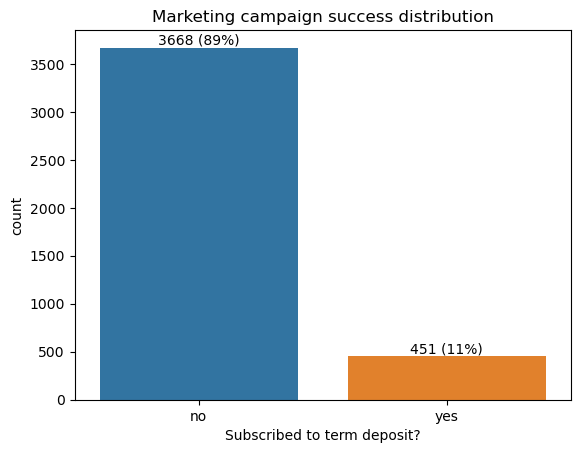

In [8]:
sns.countplot(x = "y", data = banking_df)
plt.title("Marketing campaign success distribution")
absolute_labels = banking_df["y"].value_counts()
percentage_labels = banking_df["y"].value_counts() / len(banking_df) * 100
lbls = [f'{p[0]} ({p[1]:.0f}%)' for p in zip(absolute_labels, percentage_labels)]
plt.bar_label(container=plt.gca().containers[0], labels=lbls)
plt.xlabel("Subscribed to term deposit?")
plt.show()

As can be seen, the success count of 451 is only 11%. This is a clear case of data imbalance which should be dealt with later on in the data preprocessing process, to lower the risk of "no" being predicted simply because it is much more common of an outcome. 

I will do some basic visualizations for all the numerical and categorical features.

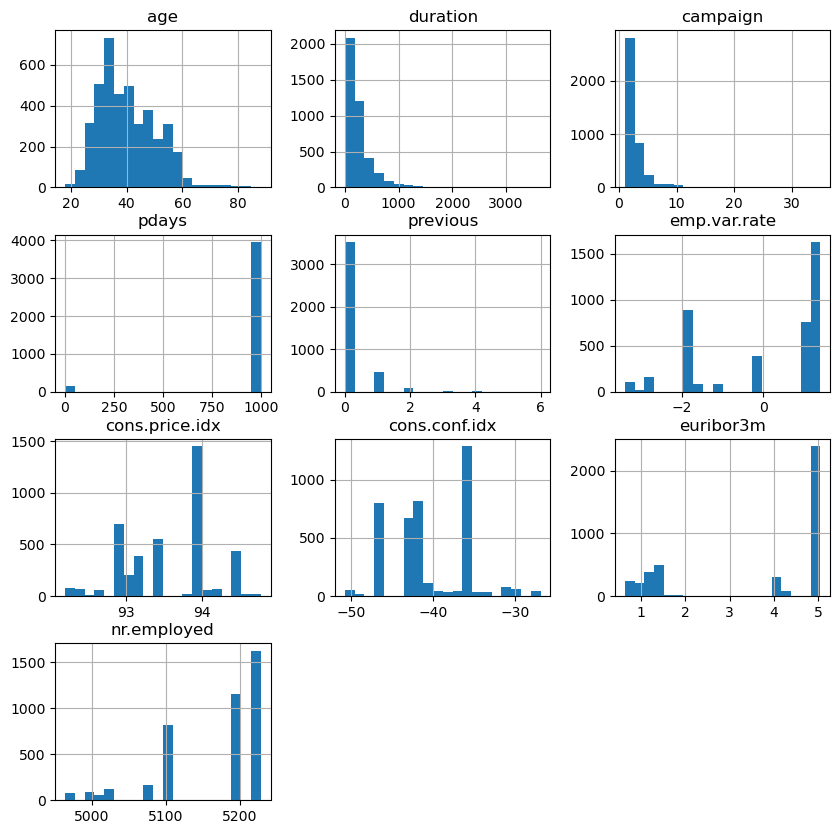

In [9]:
banking_df.hist(figsize = (10,10), bins = 20)
plt.show()


Right now, it can be observed that the vast majority of rows have pdays as being 999. This raises some questions immediately, and it is likely that '999' for the pdays column is a special value, likely indicating that the individual has never been contacted before. I will confirm this by seeing whether for all the columns in which pdays is 999, poutcome is 'nonexistent'.

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


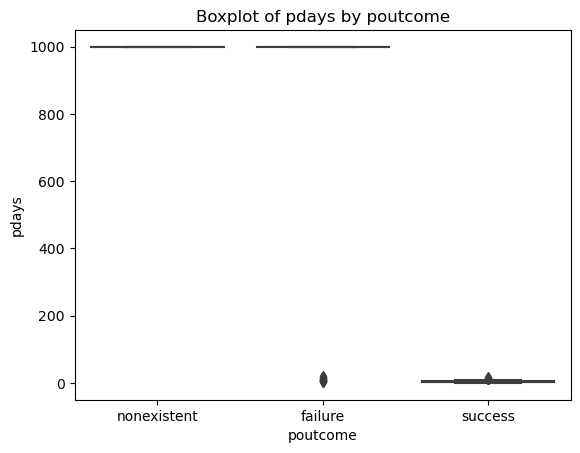

In [10]:
sns.boxplot(x = "poutcome", y = "pdays", data=banking_df)
plt.title("Boxplot of pdays by poutcome")
plt.show()

The side by side boxplot seen above confirms my hypothesis. This is because while the values for pdays are "squashed" into a very small range when customers have been previously contacted before, all customers who have not been previously contacted would have a pdays value of 999. As the column 'poutcome' already includes the information of whether or not a customer has been previously conducted and the vast majority of entries in the pdays outcome is 999, pdays is uninformative and would likely immediately be dropped at the feature selection stage due to lack of variance. Due to the fact that we are dealing with a column with over 90% missing values that would definitely be removed at feature selection, I propose dropping the column "pdays".

In [11]:
banking_df.drop(columns = ["pdays"], inplace = True)
banking_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


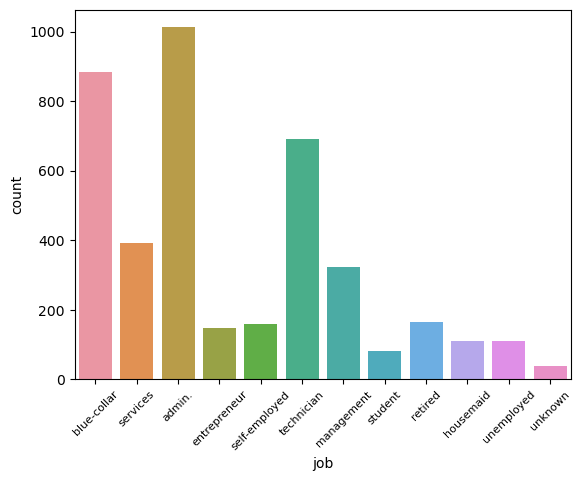

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


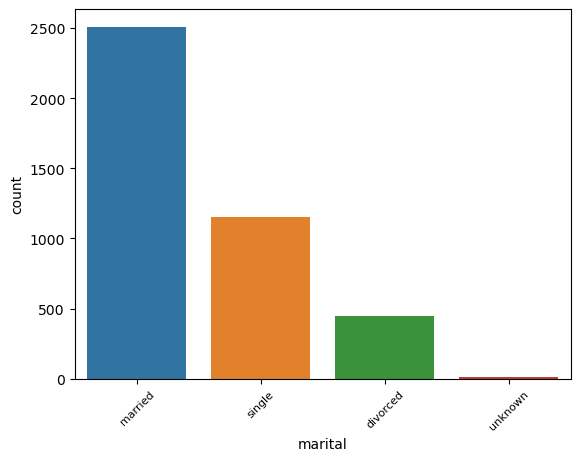

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


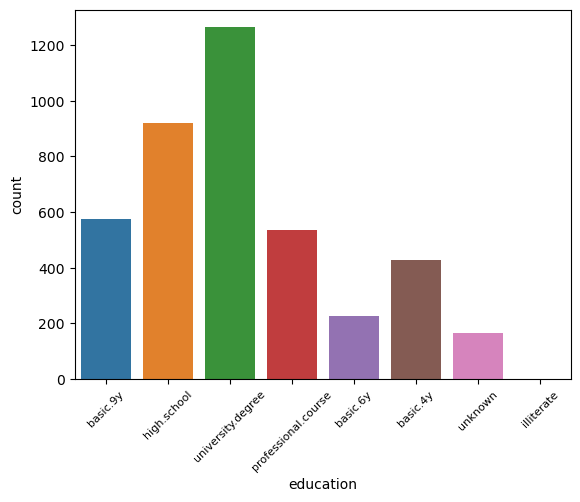

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


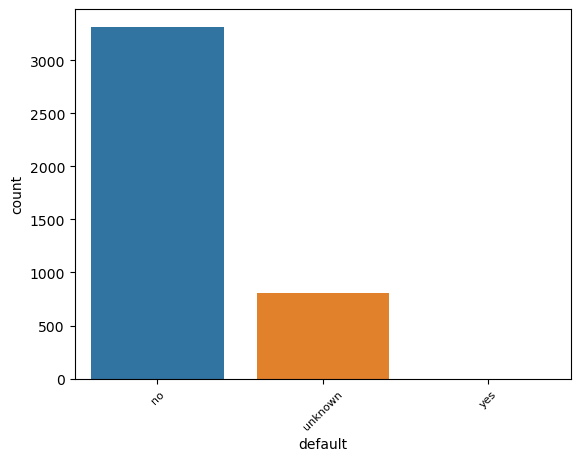

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


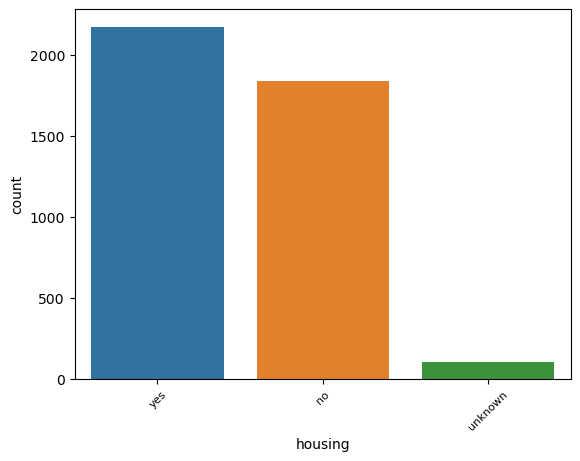

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


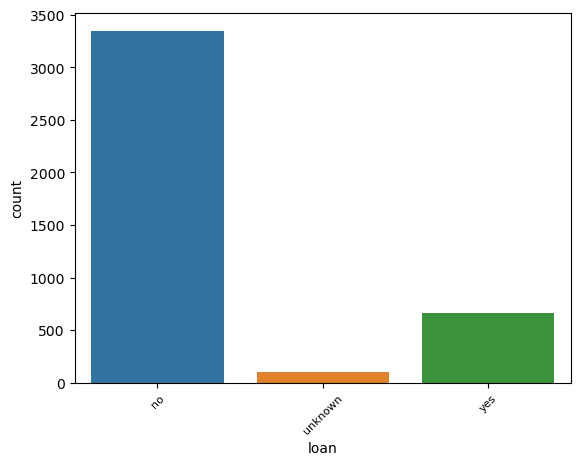

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


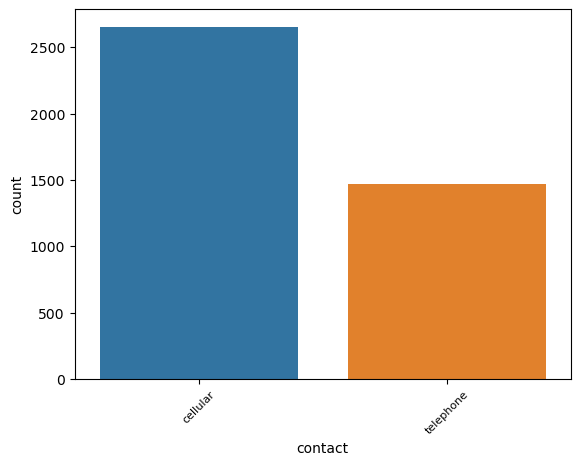

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


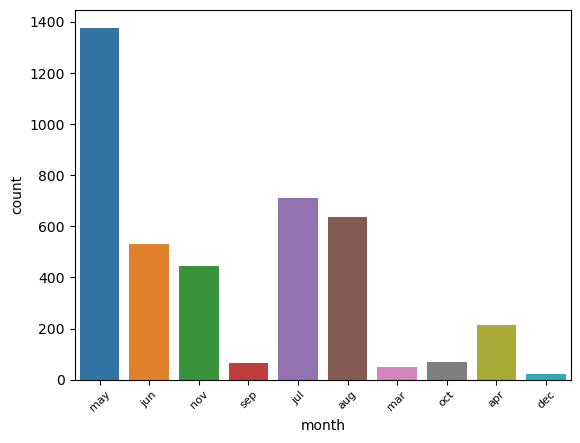

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


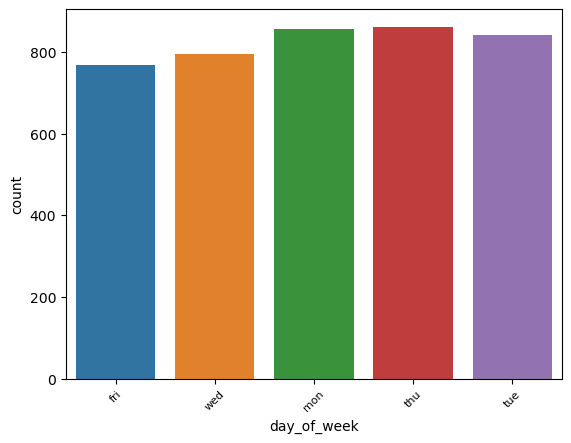

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


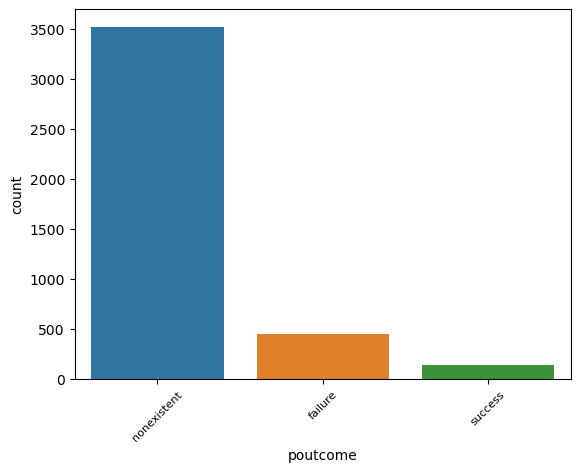

In [12]:
categorical_columns = banking_df.select_dtypes(include = ["object"])
for column in categorical_columns:
    if column == "y":
        continue
    sns.countplot(x = column, data = banking_df)
    plt.xticks(rotation = 45, fontsize = 8)
    plt.show()

It can be seen that a huge proportion of the values in the poutcome column are "nonexistent". However, we do not drop this column as the value 'nonexistent' is actually highly informative, representing customers who have never been contacted for previous campaigns before and how this may affect the target. Therefore, we will keep this and use one hot encoding to represent the three classes of values.

Next, I will examine the proportion of people who will subscribe to the term deposit based on categorical features such as job and marital status. This is because I have a hypothesis that those of certain employment/educational backgrounds are more likely to subscribe than others. 

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

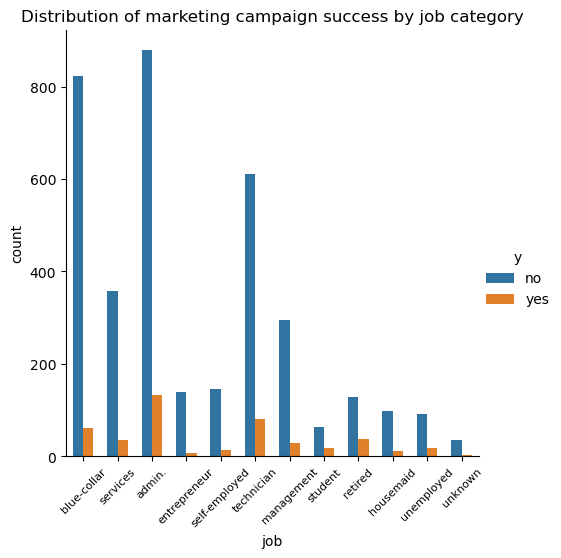

y                    no       yes
job                              
admin.         0.868577  0.131423
blue-collar    0.930995  0.069005
entrepreneur   0.945946  0.054054
housemaid      0.900000  0.100000
management     0.907407  0.092593
retired        0.771084  0.228916
self-employed  0.918239  0.081761
services       0.910941  0.089059
student        0.768293  0.231707
technician     0.884226  0.115774
unemployed     0.828829  0.171171
unknown        0.897436  0.102564


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

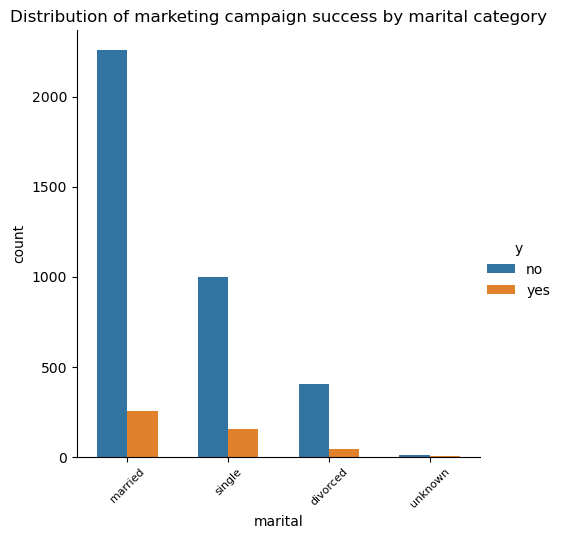

y               no       yes
marital                     
divorced  0.903587  0.096413
married   0.899562  0.100438
single    0.865568  0.134432
unknown   0.909091  0.090909


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

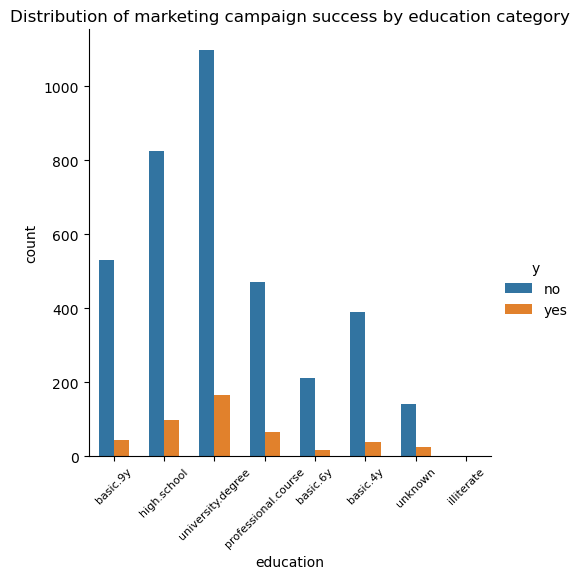

y                          no       yes
education                              
basic.4y             0.911422  0.088578
basic.6y             0.925439  0.074561
basic.9y             0.925087  0.074913
high.school          0.894680  0.105320
illiterate           1.000000  0.000000
professional.course  0.878505  0.121495
university.degree    0.869462  0.130538
unknown              0.844311  0.155689


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

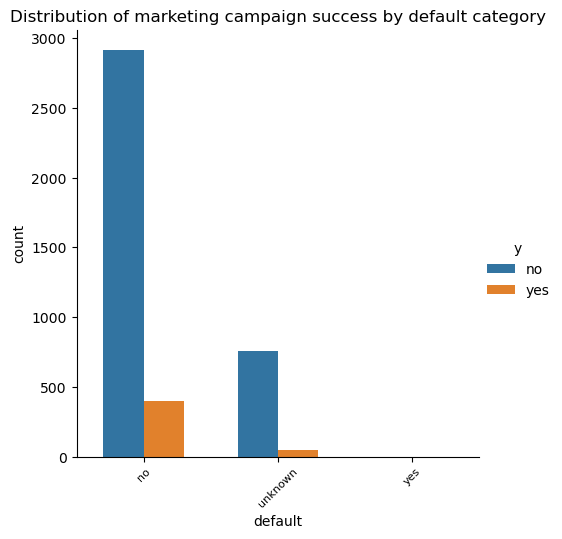

y              no       yes
default                    
no       0.878733  0.121267
unknown  0.938979  0.061021
yes      1.000000  0.000000


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

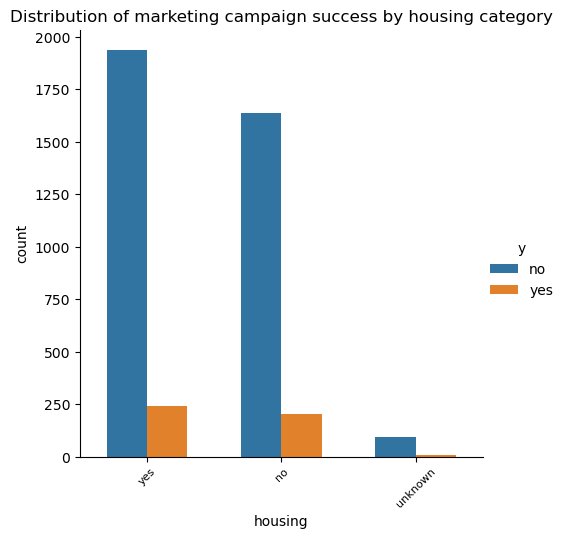

y              no       yes
housing                    
no       0.890158  0.109842
unknown  0.914286  0.085714
yes      0.889655  0.110345


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

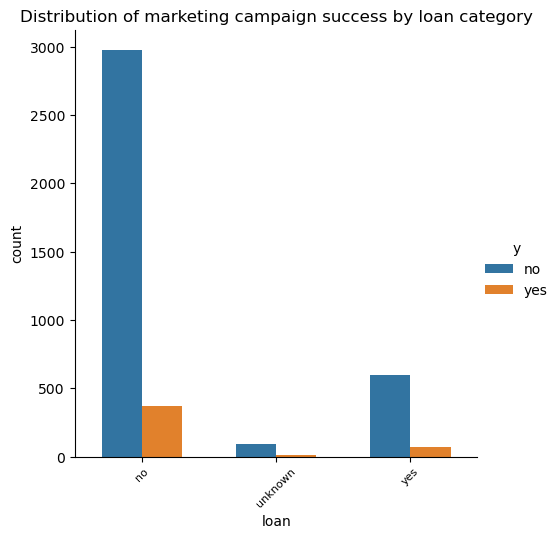

y              no       yes
loan                       
no       0.888325  0.111675
unknown  0.914286  0.085714
yes      0.897744  0.102256


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

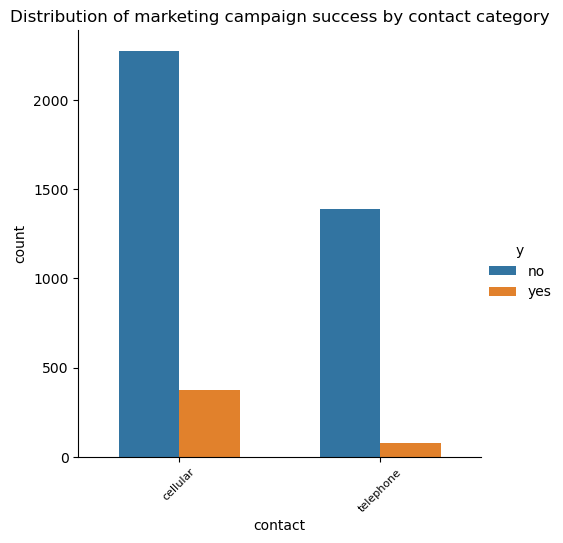

y                no       yes
contact                      
cellular   0.858597  0.141403
telephone  0.948194  0.051806


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

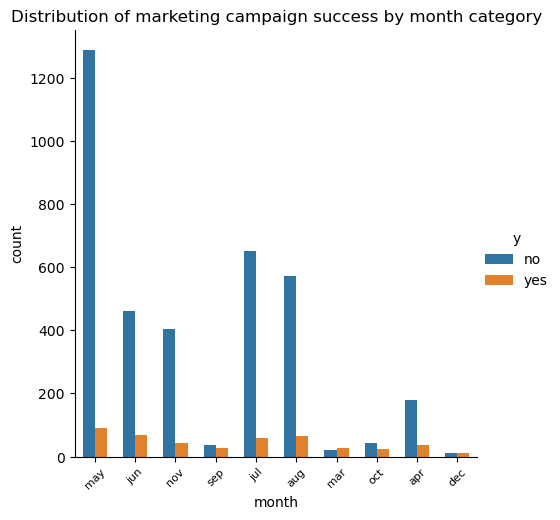

y            no       yes
month                    
apr    0.832558  0.167442
aug    0.899371  0.100629
dec    0.454545  0.545455
jul    0.917018  0.082982
jun    0.871698  0.128302
mar    0.416667  0.583333
may    0.934688  0.065312
nov    0.903587  0.096413
oct    0.637681  0.362319
sep    0.593750  0.406250


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

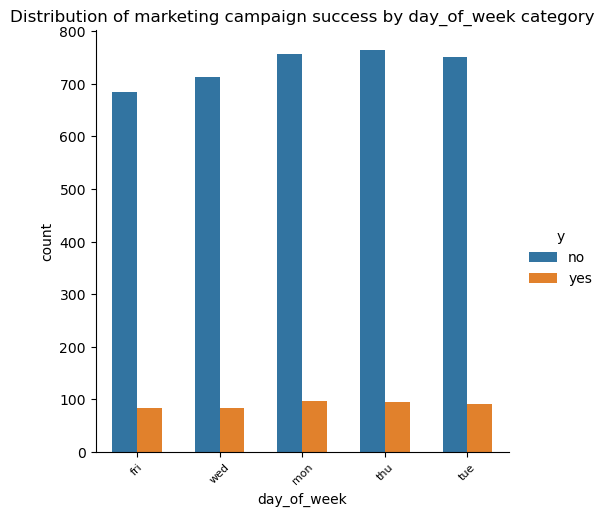

y                  no       yes
day_of_week                    
fri          0.891927  0.108073
mon          0.885380  0.114620
thu          0.888372  0.111628
tue          0.891795  0.108205
wed          0.895597  0.104403


c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

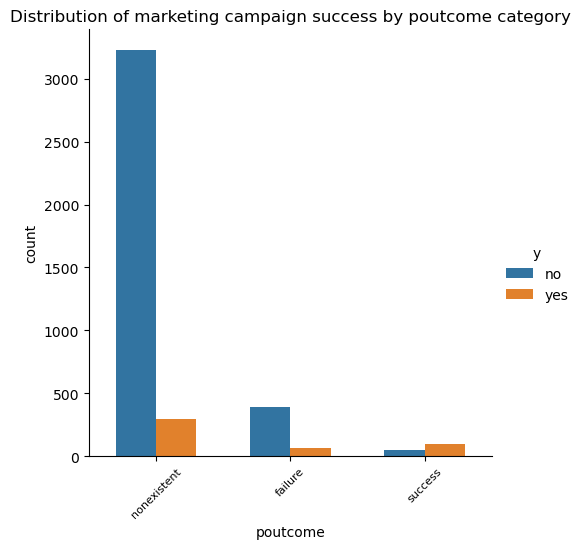

y                  no       yes
poutcome                       
failure      0.852423  0.147577
nonexistent  0.917116  0.082884
success      0.352113  0.647887


In [13]:
def yes_distribution_by_category(column):
    sns.catplot(x = column, hue = "y", kind = "count", data = banking_df, width = 0.6)
    plt.xticks(rotation = 45, fontsize = 8) # to make the labels easier to read
    plt.title(f"Distribution of marketing campaign success by {column} category")
    plt.show()
    print(pd.crosstab(banking_df[column], banking_df["y"], normalize = "index"))


for column in categorical_columns:
    if column == "y":
        continue
    yes_distribution_by_category(column)


Based on a visual inspection and the cross tabulation, it appears that certain job types such as admin, student, and retired have a higher proportion of successful attempts. In addition, it can be seen that the proportion of customers who subscribed to the term deposit is significantly higher for groups with higher educational levels, eg university degree.

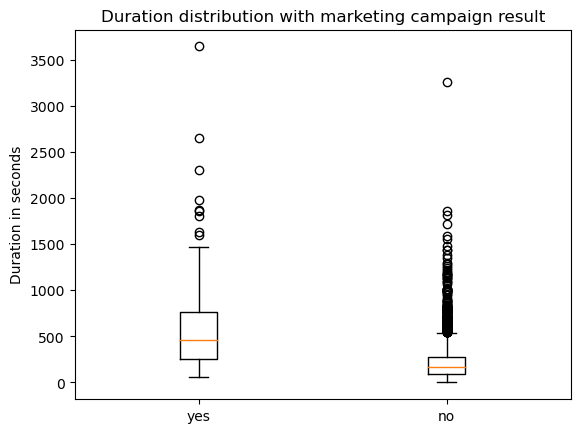

In [14]:
duration_with_yes = banking_df[banking_df["y"] == "yes"]["duration"]
duration_with_no = banking_df[banking_df["y"] == "no"]["duration"]
plt.boxplot([duration_with_yes, duration_with_no], labels = ["yes", "no"])
plt.title("Duration distribution with marketing campaign result")
plt.ylabel("Duration in seconds")
plt.show()

It can be seen that the the median and third quartile values for duration are significantly lower if the outcome is "no". 
After an analysis of the various features, it is observed that the feature "duration" should be excluded, as it leaks information about the prediction outcome. This is because "duration" can be seen as a proxy for the target variable, as it is very strongly correlated with the outcome, "y". Typically, with calls that are very short in duration, it shows that customers lack interest in subscribing.
Duration is also not available at prediction time. This is because if we know the length of the last contact with the customer before success or failure, then we already know the outcome.
We will have to drop this column before the rest of the steps to prevent data leakage. 
We cannot wait until the feature selection step to drop this column, as it would likely be treated as the most important column during feature selection.

In [15]:
banking_df.drop(columns = ["duration"], inplace = True)
banking_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


After the EDA step, the next step is to split the data into train, test and validation steps. This is because steps such as data imputation, handling class imbalance through methods such as SMOTE and ADASYN, could lead to data leakage if performed before splitting the dataset. (Eg, if missing values are imputed through mean/mode, imputation before splitting would reveal information about the entire dataset; if feature scaling is done before splitting, this would result in distributional statistics being computed on the full dataset and expose the model to the test set.)

As shown earlier, we are dealing with a case of class imbalance, as only 11% of outreach attempts lead to success. When splitting the dataset, we need stratification. 

In [16]:

from sklearn.model_selection import train_test_split 

Since we are working with only 4119 examples, the dataset is relatively small. For larger datasets, the proportion of examples used for the holdout sets can be smaller, such as a 98/1/1 split for very large datasets as even 1% of the data represents a substantial number of examples.(source: https://www.lightly.ai/blog/train-test-validation-split#:~:text=Common%20split%20ratios%20include%2070,20%25%20testing%2C%20are%20common.)
In this case, we will work with a 60/20/20 split, as it is a very common three way split ratio.

In [17]:
x = banking_df.drop("y", axis = 1)
y = banking_df["y"]
X_train_full, X_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y) #separate out the testing set first
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size = 0.25, random_state = 42, stratify = y_train_full) #separate out the validation set 
for name, labels in [("Train", y_train), ("Test", y_test), ("Validation", y_val)]:
    print(f"{name} class distribution")
    print(labels.value_counts(normalize = True))
# the class distribution is retained (89% no, 11% yes). 

Train class distribution
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64
Test class distribution
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64
Validation class distribution
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


The next step is deciding how to deal with missingness in the data. 

1. Job, marital status, housing and loan: The proportion of missing values is very low. This likely means that the missingness is non informative, and could be the result of failures during data entry. I will choose to impute these categories with the mode.
2. Education and default: The proportion of missing values for these two columns are higher than the proportion of missing values for job and marital status. In addition, I believe that unknown values in these two categories are likely to be informative. For instance, there are close to 0 entries whereby education level was listed as 'illiterate', while over 100 entries are listed as 'unknown'. It could be the case that individuals who are illiterate or did not complete any formal education simply refused to admit their actual education level. The same logic could be applied to the default column, as those who have previously defaulted on their loans may have refused to admit that information. I will treat the unknown values as a separate category during the encoding process.
3. poutcome: The proportion of 

For imputation, this has to be fitted strictly using the training set, as computing the mode from the entire dataset could lead to the model 'seeing' information from the holdout sets, leading to data leakage. 

Next, I will determine the types of categorical variables I am working with, as well as how to encode each categorical variable. 

1. Job: Nominal. There is no order between categories of jobs. 
2. Marital: Nominal. 
3. Education: Ordinal. There is a clear progression in education levels. 
4. Default: nominal. 
5. Housing and loan: Binary. As stated earlier, we will be imputing unknown values as the mode for these two columns, and thus there will only be two categories for these columns. 
6. contact: binary.
7. month, day_of_week: Cyclical. This is because Sunday loops back to Monday, December loops back to January and so on. I will consider using a cyclical encoder for converting these features into numeric columns, as this will help improve the predictive power of the model.
8. poutcome: nominal. 



In [18]:
# importing necessary libraries for data preprocessing and modeling 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,  QuantileTransformer , FunctionTransformer #use this to create sine cosine encoding
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer # replace missing values with descriptive statistic 
from sklearn.compose import ColumnTransformer # column transformer can bundle together different preprocessing steps
from sklearn.linear_model import LogisticRegression 


The first step is to generate groups of features. This is because different features will undergo different steps for data preprocessing and scaling. For instance, columns which have missing values will need to undergo imputation. Categorical variables will additionally have to be encoded into numerical values. The types of scaling method that will be used will also be different, depending on whether data is nominal/ordinal/cyclical for categorical features, as well as the scale and distribution of data.

In [19]:
# numerical columns 
numerical_columns = ["age", "campaign", "previous", "emp.var.rate", "cons.price.idx", 
                     "cons.conf.idx", "euribor3m", "nr.employed"]
# defining the sub pipeline used for the numerical columns. 
numerical_pipeline = Pipeline([("scaler", QuantileTransformer(output_distribution="normal"))])

In this case, we will use QuantileTransformer to scale the numerical columns. This is because many of the numeric columns are highly skewed or multimodal, which can affect model performance. 

There are many sources which state that machine learning algorithms tend to perform better on normally distributed variables. (https://machinelearningmastery.com/quantile-transforms-for-machine-learning/) QuantileTransformer is able to reduce the impact of outliers on data, and is therefore better able to handle skewness and multimodal data. (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html)

In [20]:
nominal_mode_impute_columns = ["job", "marital", "housing", "loan"] # these columns have missing values, but the proportion of missing values is small. 

nominal_mode_impute_pipeline = Pipeline([("imputer", SimpleImputer(strategy = "most_frequent")), 
                                         ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))])

These are nominal features which, as shown earlier, have a lower proportion of unknown values that are likely to be uninformative, eg errors caused by mistakes during data handling. Therefore, we will choose to impute the missing values with the mode values, followed by one hot encoding to convert the categorical feature into numerical values.

In [21]:
nominal_keep_columns = ["default", "contact", "poutcome"] # do not impute missing values for these columns, only encode. 
nominal_keep_pipeline = Pipeline([("encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))])

For contact, as there are no missing values, it would be unnecessary to conduct imputation. 
For default and poutcome columns, as mentioned earlier, the high proportion of unknown values are likely to be informative and they will be kept as a separate category during one hot encoding. 

In [22]:
education_categories = ["illiterate", "basic.4y", "basic.6y", "basic.9y", "high.school", "professional.course", "university.degree", "unknown"]
ordinal_columns = ["education"]
ordinal_pipeline = Pipeline([("encoder", OrdinalEncoder(categories = [education_categories], handle_unknown = "use_encoded_value", unknown_value = -1))])

In this case, I use OrdinalEncoder for education as education levels follow a progression. For instance, university degrees mean more years of formal education than a person who underwent high school only. As the "unknown" category is hypothesised to be informative, I will encode "unknown" as a separate category.

In [23]:
cyclical_columns = ["month", "day_of_week"] # march to december, and monday to friday.

# first step is to replace the month and day_of_week with corresponding numerical values
month_map = {"mar": 3, "apr": 4, "may": 5, "jun": 6, "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}
day_map = {"mon": 1, "tue": 2, "wed": 3, "thu": 4, "fri": 5}

dataframes_to_map = [X_train, X_val, X_test]

for df in dataframes_to_map:
    df["month"] = df["month"].map(month_map)
    df["day_of_week"] = df["day_of_week"].map(day_map)
    print(f"Dataframe after mapping:")
    print(df.head())


Dataframe after mapping:
      age            job  marital          education  default housing loan  \
2502   52       services  married        high.school       no     yes   no   
182    51     technician  married            unknown       no     yes   no   
1381   50       services  married        high.school       no     yes   no   
202    42  self-employed  married  university.degree       no     yes   no   
147    40     technician  married           basic.9y  unknown      no  yes   

        contact  month  day_of_week  campaign  previous     poutcome  \
2502   cellular      8            2         5         0  nonexistent   
182   telephone      6            5         3         0  nonexistent   
1381   cellular      8            1        15         0  nonexistent   
202    cellular     11            5         3         0  nonexistent   
147   telephone      5            4         4         0  nonexistent   

      emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [ ]:
import numpy as np

def encode_sin_cos(columns):
    columns = np.array(columns) # have to convert to np array, if not a pd dataframe is passed
    print(f"Datatype of input columns: {columns.dtype}")
    month = columns[:, 0] # selects all rows with the first column, which is month
    day_of_week = columns[:, 1]
    month_sin = np.sin((2 * np.pi * month) / 12)  # maximum value of month is 12
    month_cos = np.cos((2 * np.pi * month) / 12)
    day_of_week_sin = np.sin((2 * np.pi * day_of_week) / 5) # maximum value of day is 5, only goes to friday
    day_of_week_cos = np.cos((2 * np.pi * day_of_week) / 5)
    return np.column_stack((month_sin, month_cos, day_of_week_sin, day_of_week_cos))


cyclical_encoder = FunctionTransformer(func= encode_sin_cos)

cyclical_pipeline = Pipeline([("encoder", cyclical_encoder)])



In [25]:
preprocessor = ColumnTransformer(transformers = [("num", numerical_pipeline, numerical_columns), ("nominal_mode_impute", nominal_mode_impute_pipeline, nominal_mode_impute_columns), ("nominal_keep", nominal_keep_pipeline, nominal_keep_columns),
                                                ("ordinal", ordinal_pipeline, ordinal_columns), ("cyclical", cyclical_pipeline, cyclical_columns)])

Next, I will consider various feature selection methods. I considered using SelectKBest, but this turned out not to be a good choice as SelectKBest selects features using univariate statistics -- it does not consider whether variables are multicollinear, only scoring features based on their relationship with the target variable. As logistic regression requires input variables to be non multicollinear, SelectKBest is inappropriate. I then considered using Boruta or L1 regularisation for feature selection. As Boruta tends to be slower (runs on a random forest algorithm) and is less simple to implement, I will choose Boruta. 
Features that are highly correlated with each other or have a huge proportion of missing values are likely to be removed during feature selection.

In [26]:
pipe = Pipeline([("preprocessor", preprocessor), 
                 ("model", LogisticRegression(l1_ratio=1, solver = "liblinear", max_iter= 1000, C= 0.1)) ])
# the optimiser is set to liblinear because it supports lasso regularisation


The next step is to consider model training. 
Firstly, we must define some performance metrics. In this case, the distributions of labels is very imbalanced, as 89% of reach-out attempts end up in failure. This would make accuracy alone a dubious statistic, as a model can predict failure in every case and still end up with a very high accuracy. Therefore, we will also use Cohen's Kappa statistic, as it applies to imbalanced problems and measures how much better a model performs compared to a classifier that randomly makes predictions based on the frequencies of classes.
1. Precision, which shows the false positive rate, 
2. Recall, which shows the false negative rate, 
3. Accuracy, which is the total correct predictions rate. 
4. Cohen's Kappa Statistic

Secondly, we must define the baseline that we will compare our model with. The baseline chosen is a zero-rule baseline algorithm, which will predict the most common label in the training set. 


Label     : ['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


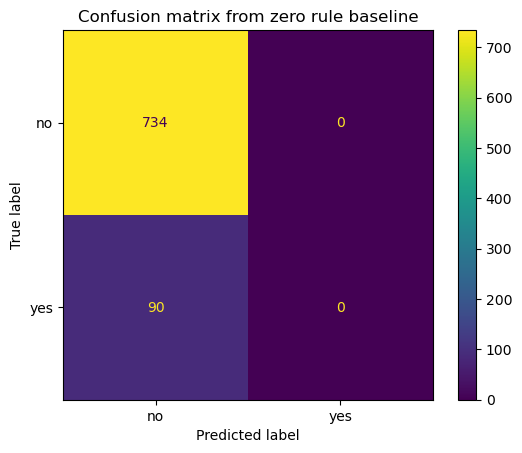

In [27]:
from sklearn.dummy import DummyClassifier 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, cohen_kappa_score

dummy_clf = DummyClassifier(strategy = "most_frequent")
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_test)
print("Label     :",list(y_test))
print("Prediction:",list(y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"Dummy Classifier Accuracy: {accuracy.round(4)*100}%")
confusion_matrix_zero_rule = confusion_matrix(y_test, y_pred, labels = dummy_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_zero_rule, display_labels = dummy_clf.classes_)
disp.plot()
plt.title("Confusion matrix from zero rule baseline")
precision = precision_score(y_test, y_pred, pos_label = "yes") # will always be 0
print(f"Precision for zero rule baseline: {precision.round(4) * 100}%") 
recall = recall_score(y_test, y_pred, pos_label = "yes") # will always be 0 
print(f"Recall for zero rule baseline: {recall.round(4) * 100}%")



It can be seen that the accuracy score of the dummy classifier is very high (89%). On the other hand, recall and precision are 0 as the classifier never predicts a successful outcome. This is a good example of how accuracy is a flawed metric for the task at hand.

c:\Users\guoyu\OneDrive\New folder\Lib\site-packages\sklearn\linear_model\_logistic.py:1171: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Label     : ['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no

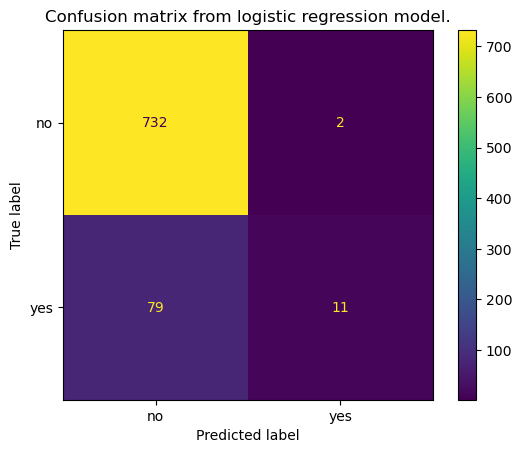

In [28]:
pipe.fit(X_train, y_train)
y_predictions_logreg = pipe.predict(X_test)
print("Label     :",list(y_test))
print("Prediction:",list(y_predictions_logreg))
accuracy = accuracy_score(y_test, y_predictions_logreg)
print(f"Logistic Regression Accuracy: {accuracy.round(4)*100}%")
confusion_matrix_logreg = confusion_matrix(y_test, y_predictions_logreg, labels = pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_logreg, display_labels = pipe.classes_)
disp.plot()
plt.title("Confusion matrix from logistic regression model.")
precision_logreg = precision_score(y_test, y_predictions_logreg, pos_label = "yes") 
print(f"Precision for logistic regression: {precision_logreg.round(4) * 100}%") 
recall_logreg = recall_score(y_test, y_predictions_logreg, pos_label = "yes")
print(f"Recall for logistic regression: {recall_logreg.round(4) * 100}%")
cohen_kappa = cohen_kappa_score(y_test, y_predictions_logreg)
print(f"Cohen's kappa statistic for logistic regression: {cohen_kappa.round(4) * 100}%")

The accuracy from this 